In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
import os

from osiris_filename import make_osiris_filename
from osiris_h5data_obj import get_cylindrical_data

In [2]:
import os

os.chdir('/home/stsoukalas/Plasma_PINNS/mode_decomposition/')

from gabi_decomp import *
from alfven_decomp import *

In [3]:
data_dir = '/home/stsoukalas/Plasma_PINNS/mode_decomposition/osiris_data_interp/' # or wherever you put the MS directory

In [4]:
ndump = 50 # frequency of diagnostic dumps in OSIRIS simulation

last_dump_num = int(sorted(os.listdir(data_dir +'/MS/FLD/MODE-0-RE/b1_cyl_m/'))[-1][-9:][:-3])
print(last_dump_num)

last_dump_simulation_idx = ndump * last_dump_num
print(last_dump_simulation_idx)

307
15350


### Get grid parameters from OSIRIS file + get field data

In [5]:
# The grid parameters are stored as attributes for every data object created by the output hdf5 files
# Therefore, all we need to do is load in a data object for the very first dumped output 
# This can be achieved by loading in the data for any field (let's use Bz), and any mode (let's use m = 0 Real)

filename = make_osiris_filename(
    'b1', last_dump_num, data_type='field', cylindrical=True,
    mode_type='re', folder=data_dir, mode=0
)

print(filename)

# This object has all the attributes we will need
# See osiris_h5data_obj.py for reference
data_obj = get_cylindrical_data(filename)

/home/stsoukalas/Plasma_PINNS/mode_decomposition/osiris_data_interp/MS/FLD/MODE-0-RE/b1_cyl_m/b1_cyl_m-0-re-000307.h5


In [6]:
dz = data_obj.DX
dr = data_obj.DY
dt = data_obj.DT[0]

nz = data_obj.NX
nr = data_obj.NY

z_grid = np.linspace(data_obj.AXIS1[0], data_obj.AXIS1[1], nz) # create linspaced 1D z-array
r_grid = np.linspace(data_obj.AXIS2[0], data_obj.AXIS2[1], nr) # create linspaced 1D z-array
t_sim = last_dump_simulation_idx * dt

# Z goes from 0 to z_max, R goes from -dr / 2 to r_max - dr / 2
print(f"dz = {dz:.3f} c / omega_pe")
print(f"dr = {dr:.3f} c / omega_pe")
print(f"dt = {dt:.3f} omega_pe^-1")
print(f"Z array endpoints: ({z_grid[0]:.3f}, {z_grid[-1]:.3f}) c / omega_pe") # zmax in the simulation was 233.33 c / omega_{pe}
print(f"R array endpoints: ({r_grid[0]:.3f}, {r_grid[-1]:.3f}) c / omega_pe") # rmax in the simulation was 120.00 c / omega_{pe}
print(f"Simulation time: {t_sim:.3f} omega_pe^-1") # time of this snapshot in omega_{pe}^{-1}

dz = 0.233 c / omega_pe
dr = 0.200 c / omega_pe
dt = 0.130 omega_pe^-1
Z array endpoints: (0.000, 233.330) c / omega_pe
R array endpoints: (-0.100, 119.900) c / omega_pe
Simulation time: 1995.500 omega_pe^-1


In [7]:
quantity = ['b1', 'b2', 'b3', 'e1', 'e2', 'e3', 'j1', 'j2', 'j3'] # -> 1 = z, 2 = r, 3 = phi
modes = [(0, 're'), (1, 're'), (1, 'im')]
data_dict = {quantity: {mode: np.zeros((nr, nz)) for mode in modes} for quantity in quantity}

for quantity in quantity:
    for mode_tuple in modes:

        data_type = 'field'
        particle  = None

        filename = make_osiris_filename(
            data_name=quantity,
            timestep=last_dump_num, 
            data_type=data_type, 
            folder=data_dir, 
            particle=particle,
            cylindrical=True,
            mode=mode_tuple[0],
            mode_type=mode_tuple[1], 
        )

        data_obj = get_cylindrical_data(filename)

        data_dict[quantity][mode_tuple] = data_obj.DATA # shape: (nr, nz)

### Visualize a few quantities

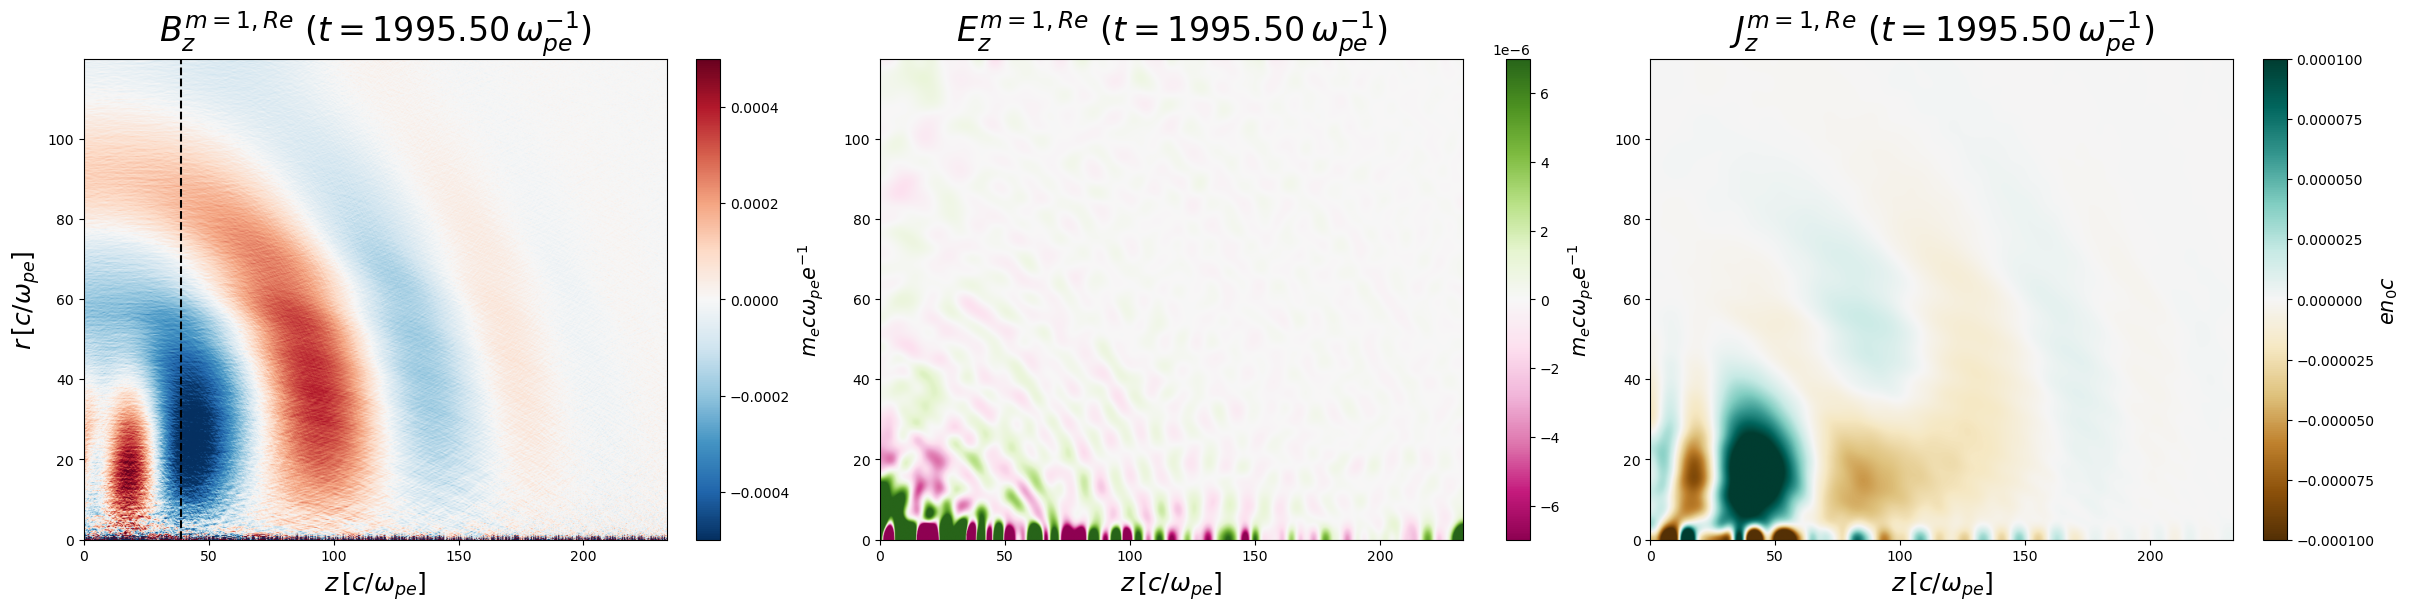

In [8]:
# Viszualize Bz, Ez, Jz for m = 1 Real 

Bz_data = data_dict['b1'][(1, 're')][1:,:] # only visualize above r = 0. You will also want to do this when interpolating modes
Ez_data = data_dict['e1'][(1, 're')][1:,:]
Jz_data = data_dict['j1'][(1, 're')][1:,:]

# Filter Ez and Jz data because they are very noisy
Ez_data = scipy.ndimage.gaussian_filter(Ez_data, sigma=10.0)
Jz_data = scipy.ndimage.gaussian_filter(Jz_data, sigma=10.0)

extent = [z_grid[0], z_grid[-1], r_grid[0], r_grid[-1]]

plt.figure(figsize=(24, 6), constrained_layout=True)

plt.subplot(1,3,1)
plt.title(r'$B_z^{m=1, Re} \, \, (t = $' + f"{t_sim:.2f}" + r'$ \, \omega_{pe}^{-1})$', fontsize=24) 
plt.xlabel(r'$z \, [c / \omega_{pe}]$', fontsize=18)
plt.ylabel(r'$r \, [c / \omega_{pe}]$', fontsize=18)
plt.imshow(Bz_data, aspect='auto', origin='lower', extent=extent, cmap='RdBu_r', vmin=-5e-4, vmax=5e-4)
plt.vlines(z_grid[len(z_grid) // 6], ymin=r_grid[1], ymax=r_grid[-1], linestyle='dashed', color='k')
cbar = plt.colorbar()
cbar.set_label(r'$m_e c \omega_{pe} e^{-1}$', fontsize=15)

plt.subplot(1,3,2)
plt.title(r'$E_z^{m=1, Re} \, \, (t = $' + f"{t_sim:.2f}" + r'$ \, \omega_{pe}^{-1})$', fontsize=24) 
plt.xlabel(r'$z \, [c / \omega_{pe}]$', fontsize=18)
plt.imshow(Ez_data, aspect='auto', origin='lower', extent=extent, cmap='PiYG', vmin=-7e-6, vmax=7e-6)
cbar = plt.colorbar()
cbar.set_label(r'$m_e c \omega_{pe} e^{-1}$', fontsize=15)


plt.subplot(1,3,3)
plt.title(r'$J_z^{m=1, Re} \, \, (t = $' + f"{t_sim:.2f}" + r'$ \, \omega_{pe}^{-1})$', fontsize=24) 
plt.xlabel(r'$z \, [c / \omega_{pe}]$', fontsize=18)
plt.imshow(Jz_data, aspect='auto', origin='lower', extent=extent, cmap='BrBG', vmin=-1e-4, vmax=1e-4)
cbar = plt.colorbar()
cbar.set_label(r'$e n_0 c$', fontsize=15)

plt.show()

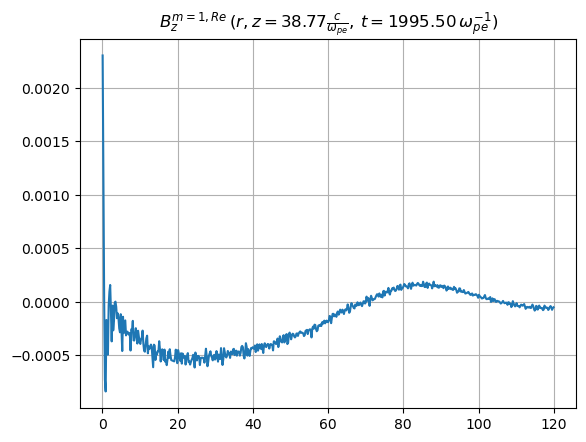

In [9]:
# Visualize Bz, m = 1 Real for an axial slice. This is what we will interpolate onto a cartesian grid

Bz_slice = data_dict['b1'][(1, 're')][1:, len(z_grid) // 6]

plt.plot(r_grid[1:], Bz_slice)
plt.title(r'$B_z^{m=1, Re} \, (r, z = $' + f"{z_grid[len(z_grid) // 6]:.2f}" + r'$\frac{c}{\omega_{pe}}, \, t = $' + f"{t_sim:.2f}" + r'$\, \omega_{pe}^{-1})$')
plt.grid(True)

### Interpolate onto a cartesian grid

In [10]:
def zack_cartesian(r_vals, dr):
    r_max = r_vals[-1]

    x = np.arange(-r_max, r_max + dr, dr)
    y = np.arange(-r_max, r_max + dr, dr)

    X, Y = np.meshgrid(x,y)

    RR = np.sqrt(X**2+Y**2)
    PHI = np.arctan2(Y,X) % (2*np.pi)

    return X, Y, RR, PHI

In [11]:
X, Y, RR, PHI = zack_cartesian(r_grid, r_grid[1]-r_grid[0])
r_flat = RR.flatten()
rr = np.clip(r_flat, r_grid[1:].min(), r_grid[1:].max())
z_slice = len(z_grid)//6

In [12]:
def interp(y0, x0=r_grid[1:], x=rr, phi_grid=PHI):
    return scipy.interpolate.interp1d(x0, y0, axis=0)(x).reshape(phi_grid.shape)

def reconstruct_plane(phi_grid, parent_field_r=data_dict['b2'], parent_field_phi=data_dict['b3'], parent_field_z=data_dict['b1'], M=1, z_slice = len(z_grid)//6):

    field_r = interp(parent_field_r[(0, 're')][1:, z_slice])
    field_phi = interp(parent_field_phi[(0, 're')][1:, z_slice])
    field_z = interp(parent_field_z[(0, 're')][1:, z_slice])

    for m in range(1, M+1):
        field_z_re = interp(parent_field_z[(m, 're')][1:,z_slice])
        field_r_re = interp(parent_field_r[(m, 're')][1:,z_slice])
        field_phi_re = interp(parent_field_phi[(m, 're')][1:,z_slice])

        field_z_im = interp(parent_field_z[(m, 'im')][1:,z_slice])
        field_r_im = interp(parent_field_r[(m, 'im')][1:,z_slice])
        field_phi_im = interp(parent_field_phi[(m, 'im')][1:,z_slice])

        cos_term = np.cos(m * phi_grid)
        sin_term = np.sin(m * phi_grid)

        field_r += field_r_re * cos_term - field_r_im * sin_term
        field_phi += field_phi_re * cos_term - field_phi_im * sin_term
        field_z += field_z_re * cos_term - field_z_im * sin_term


    return field_r, field_phi, field_z

def cartesian_rec(Br_rec, Bp_rec, Bz_rec, phi):
    # converts cylindrical reconstructed components to cartesian for a z slice
    Bx_rec_slice = Br_rec * np.cos(phi) - Bp_rec * np.sin(phi)
    By_rec_slice = Br_rec * np.sin(phi) + Bp_rec * np.cos(phi)
    Bz_rec_slice = Bz_rec

    return Bx_rec_slice, By_rec_slice, Bz_rec_slice

In [1]:
br_rec, bp_rec, bz_rec = reconstruct_plane(PHI)

NameError: name 'reconstruct_plane' is not defined

In [14]:
bx, by, bz = cartesian_rec(br_rec, bp_rec, bz_rec, PHI)

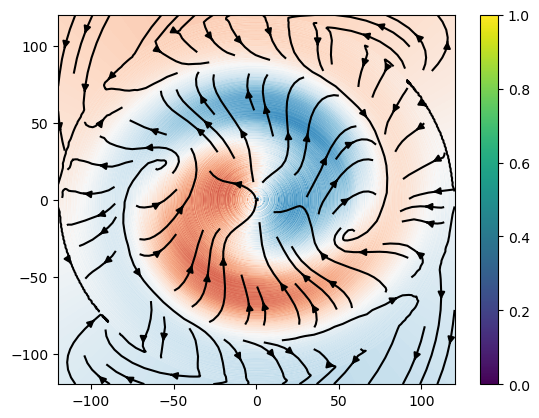

In [16]:
plt.pcolormesh(X, Y, bz, cmap='RdBu_r', vmin=-0.001, vmax=0.001)
plt.streamplot(X, Y, bx, by, density=0.8, color='black')
plt.colorbar()

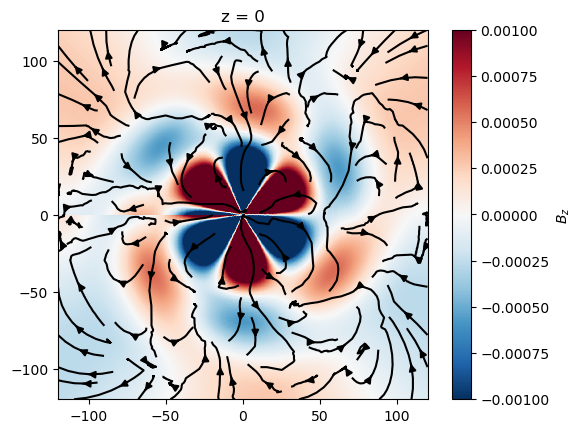

In [16]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

br_rec0, bp_rec0, bz_rec0 = reconstruct_plane(PHI)
bx0, by0, bz0 = cartesian_rec(br_rec0, bp_rec0, bz_rec0, PHI)

pcm = ax.pcolormesh(X, Y, bz0, shading="auto", vmin=-.001, vmax=0.001, cmap='RdBu_r')
strm = ax.streamplot(X, Y, bx0, by0, color="black", density=0.8)

ax.set_xlim(X.min(), X.max())
ax.set_ylim(Y.min(), Y.max())
ax.set_aspect('equal')
ax.set_title(f"z = {z_slice}")

def update(z_ind):
    global strm
    strm.lines.remove()
    for patch in ax.patches:
        patch.remove()
    
    # new data
    br_rec, bp_rec, bz_rec = reconstruct_plane(z_slice=z_ind, phi_grid=PHI)
    bx, by, bz = cartesian_rec(br_rec, bp_rec, bz_rec, PHI)

    pcm.set_array(bz.ravel())
    ax.set_title(f"z = {z_ind}")


    strm = ax.streamplot(X, Y, bx, by, color="black", density=0.8)

fig.colorbar(pcm, label=r'$B_z$')
anim = FuncAnimation(fig, update, frames=range(0, len(z_grid), 10), interval=50, blit=False)
anim.save(f'Bvec2_synthetic.mp4')